In [55]:
import gcamreader
from lxml import etree
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH    = '../output'
DB_FILE    = 'database_basexdb'
QUERY_FILE = '../output/queries/Main_queries.xml'

MTC_TO_GTCO2 = (44 / 12) / 1000

conn = gcamreader.querymi.LocalDBConn(DB_PATH, DB_FILE)
query_tree = etree.parse(QUERY_FILE)

# Map fqName → (display label, color)
SCENARIO_MAP = {
    'Reference':       ('Reference',  '#aaaaaa'),
    'GCAM_SSP1_1p9':  ('SSP1-1.9',   '#1a7340'),
    'GCAM_SSP1_2p6':  ('SSP1-2.6',   '#52b788'),
    'GCAM_SSP2_3p7':  ('SSP2-3.7',   '#3498db'),
    'GCAM_SSP2_4p5':  ('SSP2-4.5',   '#1a5276'),
}

db = conn.listScenariosInDB()
print(db[['name','date','fqName']].to_string())
print()
print('Matched:', [n for n in db['name'] if n in SCENARIO_MAP])

Database scenarios: Reference, GCAM_SSP4, GCAM_SSP5, GCAM_SSP1, GCAM_SSP2, GCAM_SSP3, GCAM_SSP1_1p9, GCAM_SSP1_2p6, GCAM_SSP2_3p7, GCAM_SSP2_4p5
            name                      date                                  fqName
0      Reference  2026-25-3T09:58:35+01:00      Reference 2026-25-3T09:58:35+01:00
1      GCAM_SSP4  2026-25-3T11:16:54+01:00      GCAM_SSP4 2026-25-3T11:16:54+01:00
2      GCAM_SSP5  2026-25-3T11:26:44+01:00      GCAM_SSP5 2026-25-3T11:26:44+01:00
3      GCAM_SSP1  2026-25-3T11:36:00+01:00      GCAM_SSP1 2026-25-3T11:36:00+01:00
4      GCAM_SSP2  2026-25-3T11:45:07+01:00      GCAM_SSP2 2026-25-3T11:45:07+01:00
5      GCAM_SSP3  2026-25-3T11:54:07+01:00      GCAM_SSP3 2026-25-3T11:54:07+01:00
6  GCAM_SSP1_1p9  2026-25-3T13:17:45+01:00  GCAM_SSP1_1p9 2026-25-3T13:17:45+01:00
7  GCAM_SSP1_2p6  2026-25-3T18:44:27+01:00  GCAM_SSP1_2p6 2026-25-3T18:44:27+01:00
8  GCAM_SSP2_3p7  2026-25-3T20:57:35+01:00  GCAM_SSP2_3p7 2026-25-3T20:57:35+01:00
9  GCAM_SSP2_4p5  2026-25

In [56]:
def get_query(tree, title, tag):
    for elem in tree.getroot().iter(tag):
        if elem.get('title') == title:
            return gcamreader.querymi.Query(elem)
    raise KeyError(f'Query not found: {title}')

def plot_scenarios(df, y_col, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(10, 5))
    for scenario, grp in df.groupby('scenario'):
        base = scenario.split(',')[0]
        if base not in SCENARIO_MAP:
            continue
        label, color = SCENARIO_MAP[base]
        ax.plot(grp['Year'], grp[y_col], color=color, linewidth=2, label=label)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)
    ax.grid(axis='y', linewidth=0.4, alpha=0.4)
    plt.tight_layout()
    plt.title(title)
    plt.savefig(f'../output/gcam_diagnostics/{filename}', dpi=150)
    plt.show()

# Scenarios to query: those in SCENARIO_MAP that exist in DB
query_scenarios = [n for n in db['name'] if n in SCENARIO_MAP]

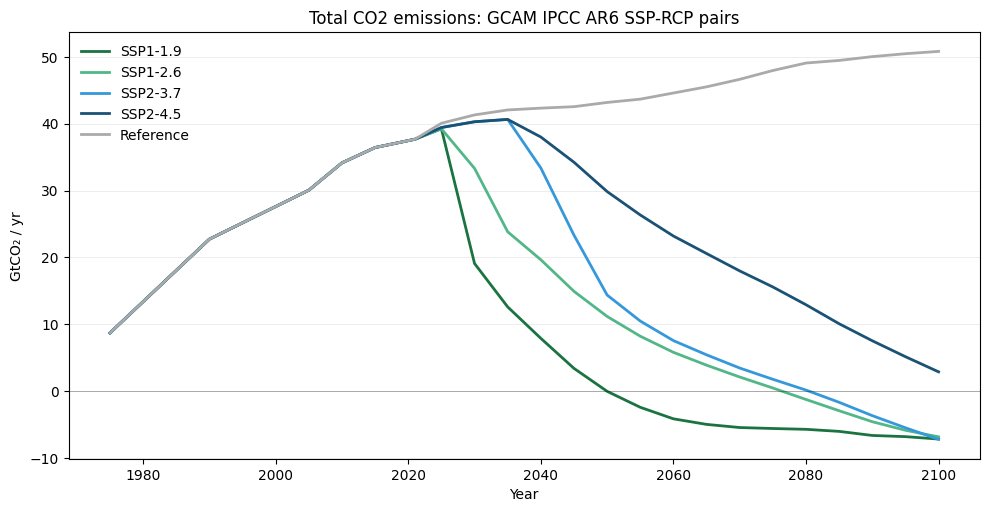

In [57]:
q = get_query(query_tree, 'CO2 emissions by region', 'emissionsQueryBuilder')
df_co2 = (
    conn.runQuery(q, scenarios=query_scenarios)
    .groupby(['scenario', 'Year'], as_index=False)['value']
    .sum()
    .assign(GtCO2=lambda d: d['value'] * MTC_TO_GTCO2)
    .drop(columns='value')
)
plot_scenarios(df_co2, 'GtCO2', 'GtCO₂ / yr',
               'Total CO2 emissions: GCAM IPCC AR6 SSP-RCP pairs',
               'policy_co2_total.png')

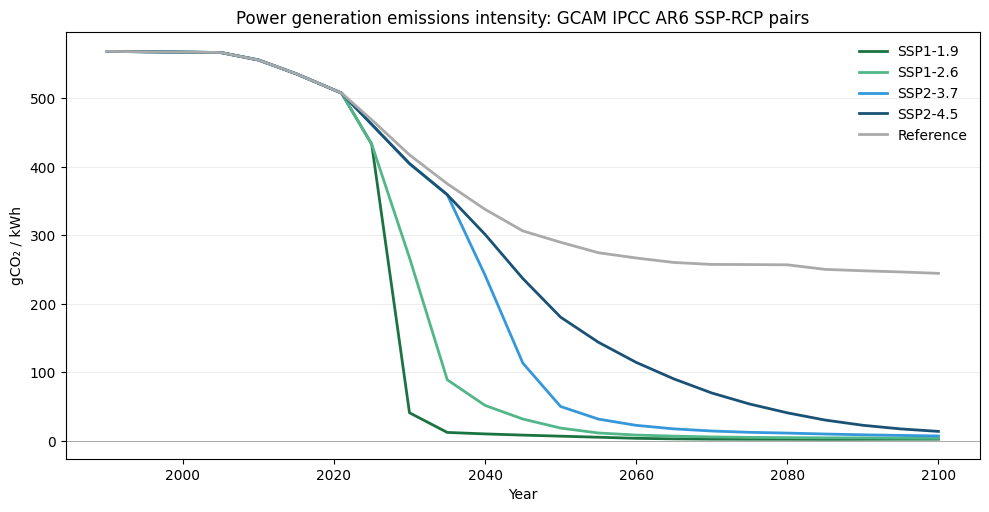

In [58]:
q_co2 = get_query(query_tree, 'CO2 emissions by sector (excluding resource production)', 'emissionsQueryBuilder')
df_sec = conn.runQuery(q_co2, scenarios=query_scenarios)
elec_sectors = [s for s in df_sec['sector'].unique() if s.startswith('elec_')]

df_elec_co2 = (
    df_sec[df_sec['sector'].isin(elec_sectors)]
    .groupby(['scenario', 'Year'], as_index=False)['value']
    .sum()
    .assign(MtCO2=lambda d: d['value'] * (44 / 12))
    .drop(columns='value')
)

df_gen = (
    conn.runQuery(get_query(query_tree, 'elec gen by region (incl CHP)', 'supplyDemandQuery'), scenarios=query_scenarios)
    .groupby(['scenario', 'Year'], as_index=False)['value']
    .sum()
    .assign(TWh=lambda d: d['value'] * 277.78)
    .drop(columns='value')
)

df_intensity = df_elec_co2.merge(df_gen, on=['scenario', 'Year'])
df_intensity['gCO2_per_kWh'] = (df_intensity['MtCO2'] * 1e6) / (df_intensity['TWh'] * 1e9) * 1e6

plot_scenarios(df_intensity, 'gCO2_per_kWh', 'gCO₂ / kWh',
               'Power generation emissions intensity: GCAM IPCC AR6 SSP-RCP pairs',
               'policy_power_intensity.png')

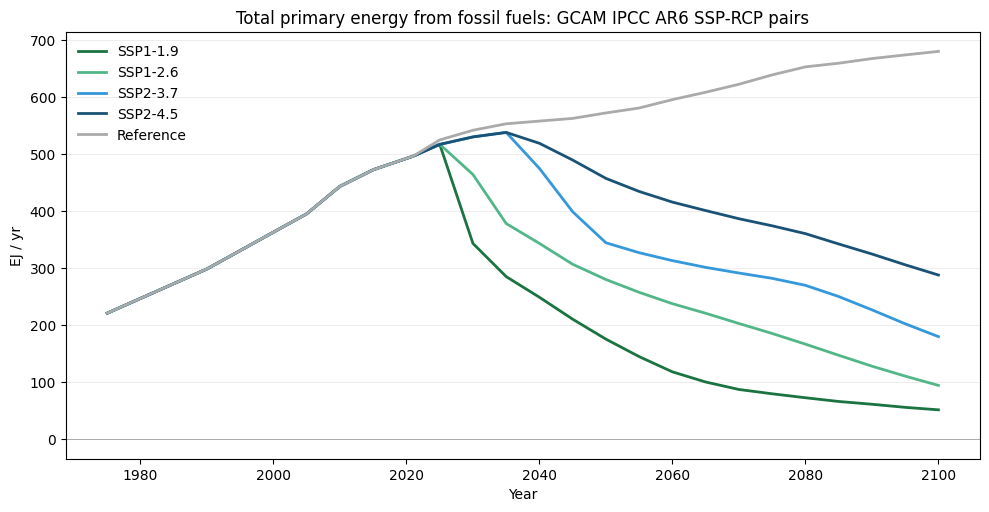

In [59]:
df_fossil = (
    conn.runQuery(get_query(query_tree, 'resource production', 'supplyDemandQuery'), scenarios=query_scenarios)
    .pipe(lambda d: d[d['resource'].isin(['coal', 'crude oil', 'natural gas']) & (d['Units'] == 'EJ')])
    .groupby(['scenario', 'Year'], as_index=False)['value']
    .sum()
    .rename(columns={'value': 'EJ'})
)
plot_scenarios(df_fossil, 'EJ', 'EJ / yr',
               'Total primary energy from fossil fuels: GCAM IPCC AR6 SSP-RCP pairs',
               'policy_fossil_primary.png')